<div class="alert alert-success"> 
        <h1 align="center" style="color:chocolate;">🐦Birdcleff Prediction Analysis🐤
</h1>  
     
</div>


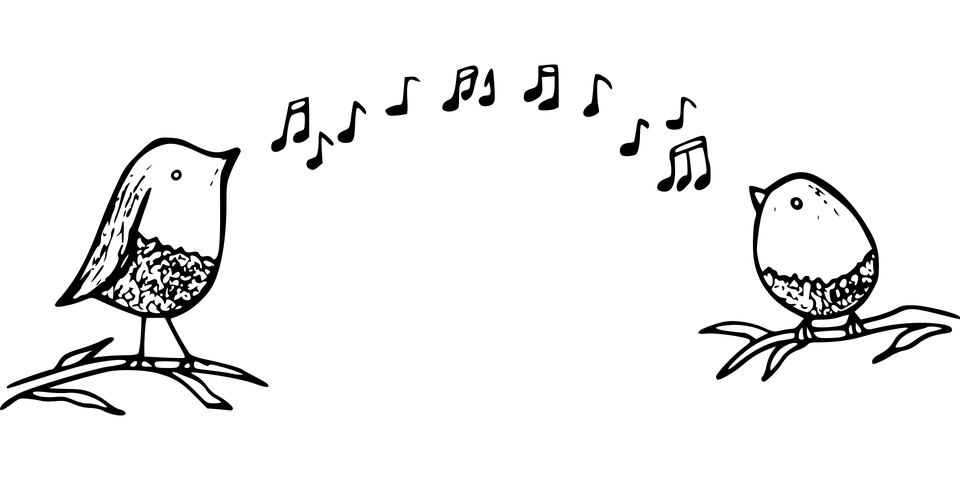
<h1><center>🐦Bird sound Prediction🦆</center></h1>

<div style="background-color: black; padding: 20px; border-radius: 10px; margin: 20px auto; max-width: 600px;">
    <center>
        <div style="background-color: white; padding: 20px; border-radius: 10px;">
            <b style="font-size: 24px; color: #ff6600;">👏😊 &nbsp; IF YOU FIND THIS HELPFUL, PLEASE UPVOTE! &nbsp; 💢👏</b>
            <div style="margin-top: 20px; font-size: 18px; color: black;">
                🥽🖥This took quite a bit of effort on my part, and while it might seem trivial, 🏆🏆receiving your appreciation means a lot to me! 😅🎃 Your upvotes inspire me to keep creating helpful content like this🖥🍱.
            </div>
        </div>
    </center>
</div>

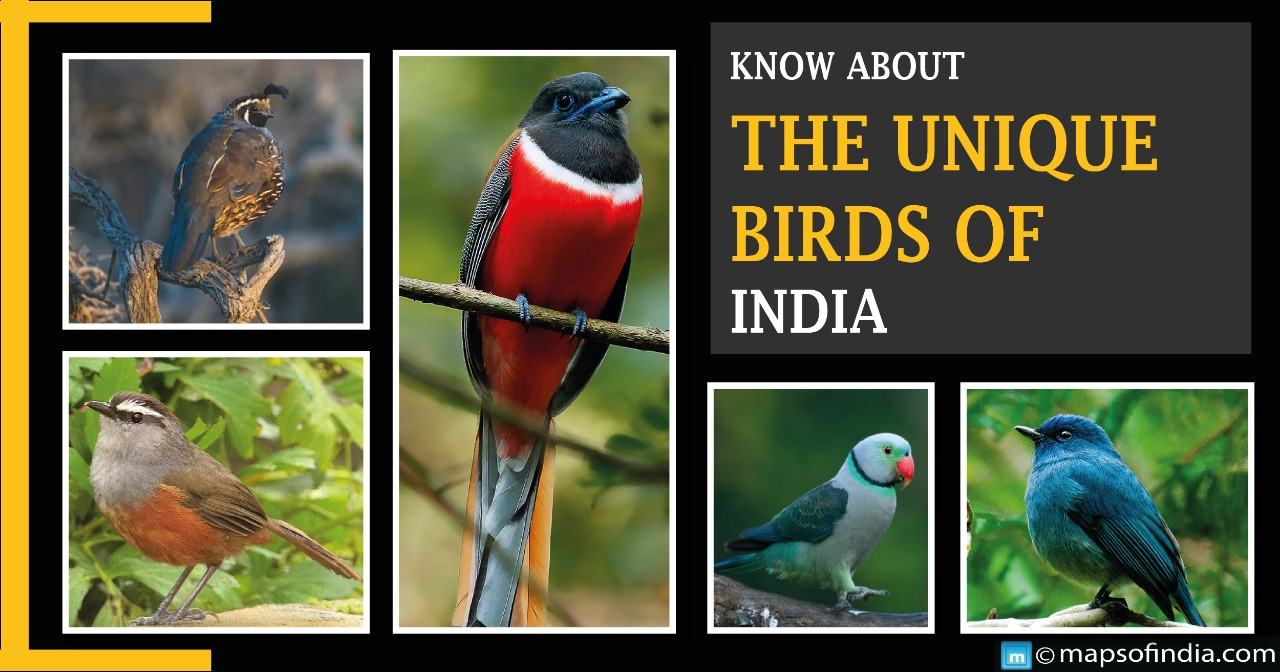

<div style="border-radius:10px; border:#DEB887 solid; padding: 15px; background-color: white; font-size:100%; text-align:left">

<h3 align="center"><font color='#DAA520'>💡 Introduction :</font></h3>
    
**Objective**: The competition aims to advance biodiversity monitoring efforts in the Western Ghats, a Global Biodiversity Hotspot in India, by leveraging machine learning techniques to identify under-studied Indian bird species through their calls.

**Dataset**: Participants are provided with a dataset consisting of audio recordings of bird calls from the Western Ghats region, along with associated metadata such as species labels, geographic coordinates, and recording details. Additionally, there are test soundscapes and unlabeled audio data for evaluation.

**Task**: Participants are tasked with developing computational solutions to process the audio data and accurately classify bird species present in the recordings. The competition focuses on identifying endemic species, detecting endangered species with limited training data, and classifying poorly understood nocturnal species.

**Collaborators**: The competition is collaboratively organized by various institutions including the Chemnitz University of Technology, Google Research, Indian Institute of Science Education and Research (IISER) Tirupati, K. Lisa Yang Center for Conservation Bioacoustics at the Cornell Lab of Ornithology, LifeCLEF, and Xeno-canto.

**Significance**: Successful solutions developed in the competition will contribute to more comprehensive and efficient monitoring of avian populations in the Western Ghats. This, in turn, will aid conservation efforts by providing insights into biodiversity trends and informing targeted conservation actions.

<div style="border-radius:10px; border:#DEB887 solid; padding: 15px; background-color: white; font-size:150%; text-align:left">

<h3 align="center"><font color='#DAA520'>🔱 Evalaution Metric💢 :</font></h3>
    
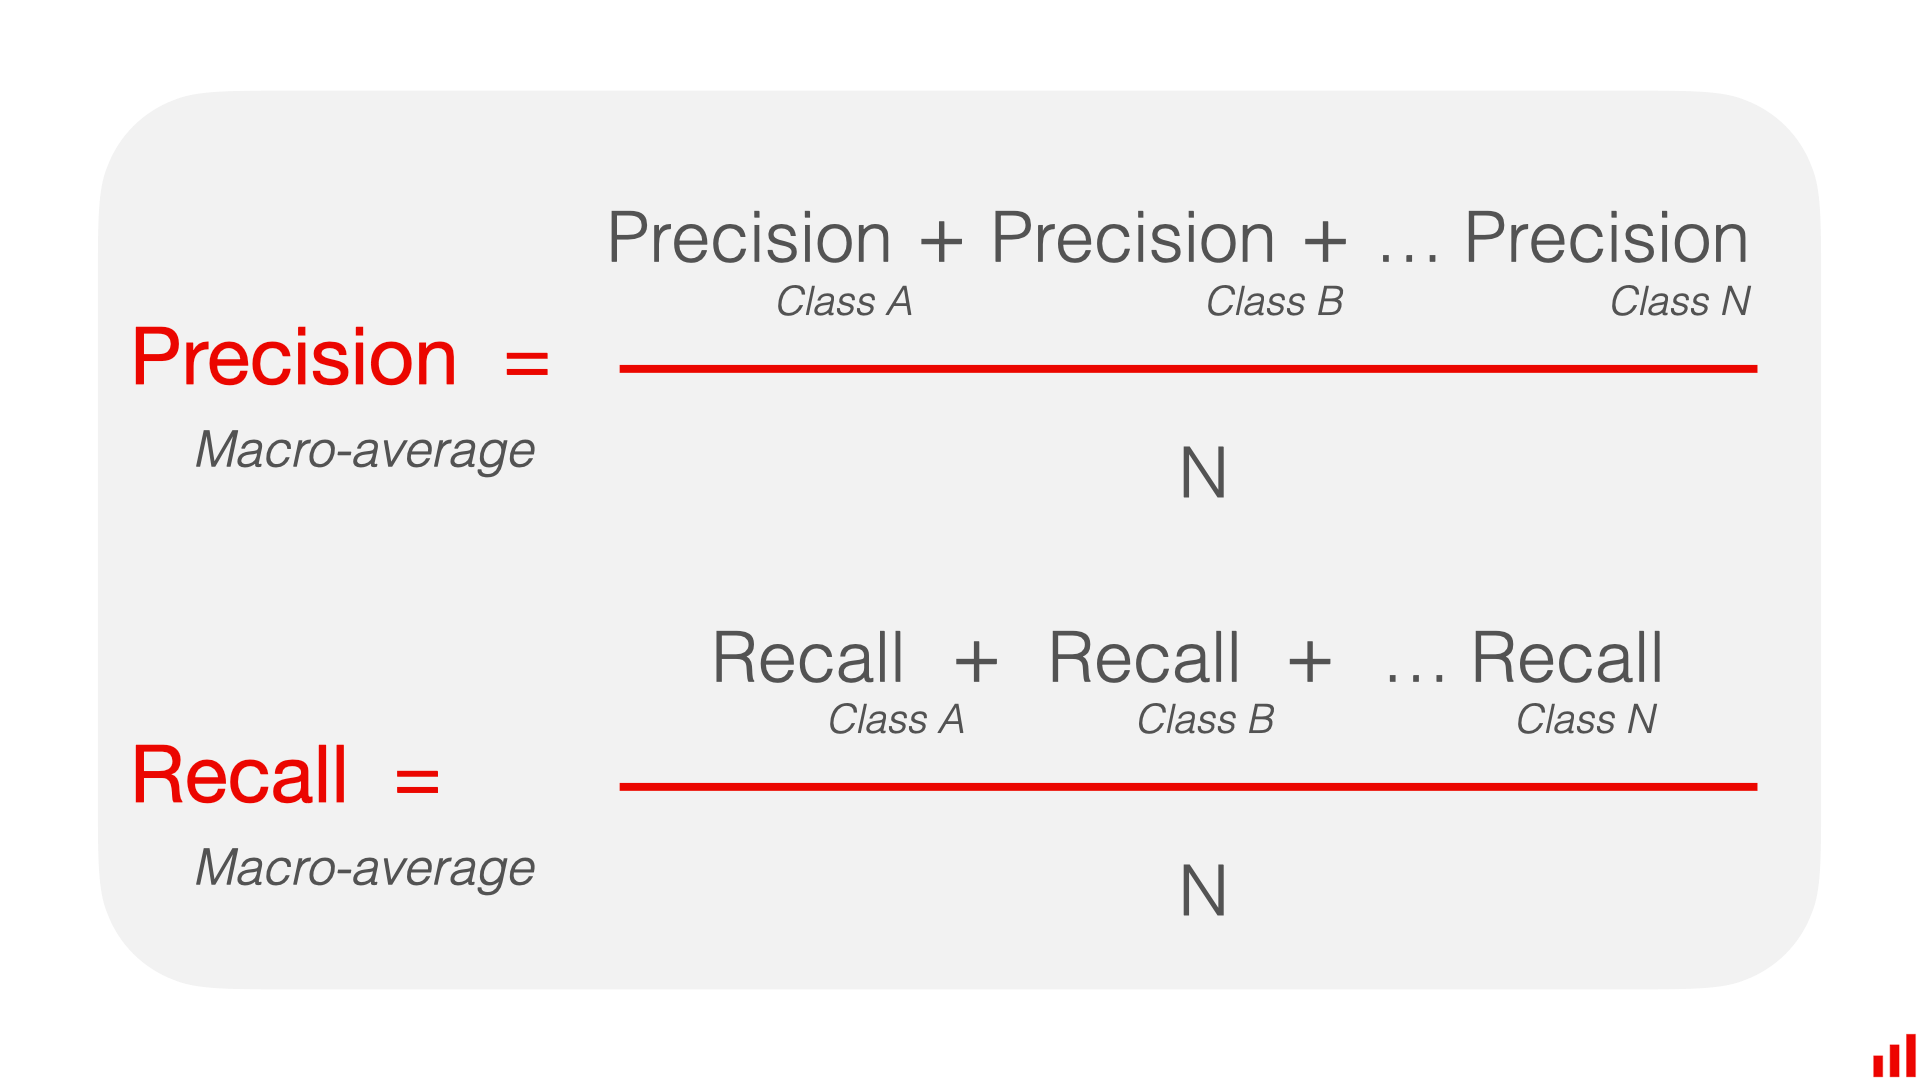


In [ ]:
import sys, os
sys.path.append('/kaggle/input/efficientnet-keras-dataset/efficientnet_kaggle')
!pip install -q /kaggle/input/tensorflow-extra-lib-ds/tensorflow_extra-1.0.2-py3-none-any.whl --no-deps

In [ ]:
import tensorflow as tf
tf.get_logger().setLevel('ERROR')
tf.autograph.set_verbosity(0)
import os
import pandas as pd
import numpy as np
import random
from glob import glob
from tqdm import tqdm
tqdm.pandas()
import gc
import librosa
import sklearn
import time
import glob
import shutil

import tensorflow as tf
tf.config.optimizer.set_jit(True) 
import tensorflow_io as tfio
import tensorflow.keras.backend as K
import matplotlib.pyplot as plt

import efficientnet.tfkeras as efn
import tensorflow_extra as tfe
import warnings
warnings.filterwarnings('ignore')
import seaborn as sns
from matplotlib.offsetbox import OffsetImage, AnnotationBbox
import matplotlib.image as mpimg


<div style="border-radius:10px; border:#DEB887 solid; padding: 15px; background-color: WHITE; font-size:100%; text-align:left">

<h3 align="center"><font color='#DAA520'>💡 About Bird Species :</font></h3>
    
**Diversity**: India boasts over 1,300 species of birds, reflecting its rich avifauna.

**Endemism**: The country is home to several endemic bird species found nowhere else, such as the Indian Peafowl and the Nilgiri Laughingthrush.

**Migration**: India serves as a vital wintering ground for migratory birds, attracting species from various regions during the winter months.

**Threats**: Habitat loss, poaching, pollution, and climate change pose significant threats to bird species in India, with many being classified as endangered or vulnerable.

**Cultural Importance**: Birds hold cultural and religious significance in Indian mythology, folklore, and art, with iconic species like the Indian Peafowl being national symbols.

**Conservation**: Conservation efforts in India include the establishment of protected areas, wildlife sanctuaries, and conservation projects aimed at safeguarding bird species and their habitats
</div>

In [ ]:
df = pd.read_csv('/kaggle/input/birdclef-2024/train_metadata.csv')

In [ ]:
df.head()

In [ ]:
df.columns

In [ ]:
df.dtypes

In [ ]:
bird_path = '/kaggle/input/birdcall-recognition-data/blue bird.jpg'
bird = mpimg.imread(bird_path)
imagebox = OffsetImage(bird, zoom=0.5)

xy = (0.5, 0.7)
ab = AnnotationBbox(imagebox, xy, frameon=False, pad=1, xybox=(130, 300))
label_counts = df['primary_label'].value_counts()
plt.figure(figsize=(45, 10))
ax = sns.barplot(x=label_counts.index, y=label_counts.values, palette="hls")
ax.add_artist(ab)


plt.title("Bird Species", fontsize=16)
plt.xticks(rotation=90, fontsize=15)
plt.yticks(fontsize=13)
plt.ylabel("Frequency", fontsize=20)
plt.xlabel("Bird Species", fontsize=20)
plt.gcf().set_facecolor('lightgrey')  # Set background color of the entire figure

plt.show()

In [ ]:
bird_path = '/kaggle/input/birdcall-recognition-data/fluff ball.jpg'
bird = mpimg.imread(bird_path)
imagebox = OffsetImage(bird, zoom=0.5)

xy = (0.5, 0.7)
ab = AnnotationBbox(imagebox, xy, frameon=False, pad=1, xybox=(13, 100))
plt.figure(figsize=(24, 16))
sns.scatterplot(x='latitude', y='longitude', data=df, color='skyblue')
plt.gca().add_artist(ab)

plt.title("Geographic Distribution of Recordings", fontsize=30)
plt.xlabel("Latitude", fontsize=30)
plt.ylabel("Longitude", fontsize=30)
plt.xticks(fontsize=20)
plt.yticks(fontsize=20)
plt.gcf().set_facecolor('lightgrey')  # Set background color of the entire figure

plt.show()

In [ ]:
bird_path = '/kaggle/input/birdcall-recognition-data/green bird.jpg'
bird = mpimg.imread(bird_path)
imagebox = OffsetImage(bird, zoom=0.5)

xy = (0.5, 0.7)
ab = AnnotationBbox(imagebox, xy, frameon=False, pad=1, xybox=(3,15000))
plt.figure(figsize=(30,15))
sns.countplot(x='license', data=df, palette='hls')
plt.gca().add_artist(ab)
plt.title("Distribution of Recording Licenses", fontsize=20)
plt.xlabel("License", fontsize=20)
plt.ylabel("Frequency", fontsize=20)
plt.xticks(rotation=45, fontsize=20)
plt.yticks(fontsize=20)
plt.gcf().set_facecolor('lightgrey')  # Set background color of the entire figure

plt.show()

In [ ]:
import random
unique_authors = df['author'].unique()
selected_authors = random.sample(list(unique_authors), k=40)  
df_selected_authors = df[df['author'].isin(selected_authors)]


bird_path = '/kaggle/input/birdcall-recognition-data/multicolor bird.jpg'
bird = mpimg.imread(bird_path)
imagebox = OffsetImage(bird, zoom=0.5)

xy = (0.5, 0.7)
ab = AnnotationBbox(imagebox, xy, frameon=False, pad=1, xybox=(30,45))


plt.figure(figsize=(45, 15))
sns.countplot(x='author', data=df_selected_authors, palette='hls')
plt.gca().add_artist(ab)
plt.title("Distribution of Recording Authors", fontsize=30)
plt.xlabel("Author", fontsize=30)
plt.ylabel("Frequency", fontsize=30)
plt.xticks(rotation=90, fontsize=30)
plt.yticks(fontsize=20)
plt.gcf().set_facecolor('lightgrey')  # Set background color of the entire figure

plt.show()

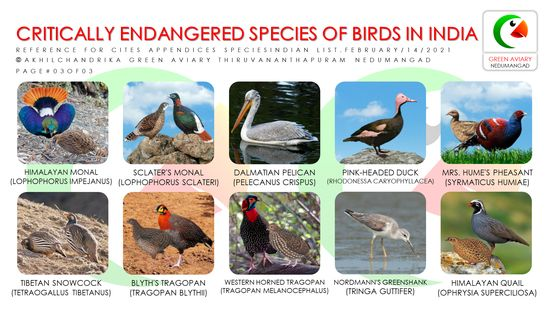

Malabar Grey Hornbill (Ocyceros griseus):
Protection of habitat through preserving old-growth forests.
Combating deforestation, habitat fragmentation, and illegal hunting.
Nilgiri Wood Pigeon (Columba elphinstonii):
Protecting montane forest habitat from deforestation and degradation.
Focusing on preserving connectivity between fragmented forest patches.
Blue-winged Parakeet (Psittacula columboides):
Protecting forest habitat and nesting sites.
Addressing threats such as deforestation, habitat loss, and illegal trade.
Nilgiri Pipit (Anthus nilghiriensis):
Preservation and restoration of montane grassland habitats.
Sustainable land management practices and protection from invasive species.
Black-and-orange Flycatcher (Ficedula nigrorufa):
Protecting forest habitat from deforestation and fragmentation.
Maintaining forest integrity and mitigating climate change impacts.
Nilgiri Flycatcher (Eumyias albicaudatus):
Preserving shola forest habitat and montane grasslands.
Protecting habitats from degradation, invasive species, and human disturbances.
White-bellied Blue Robin (Sholicola albiventris):
Protection of montane forest habitat from deforestation and fragmentation.
Preserving the integrity of shola forests and mitigating human impacts.
Rufous Babbler (Turdoides subrufa):
Preservation of forest habitat and protection from degradation.
Maintaining connectivity between fragmented forest patches and addressing threats like deforestation and invasive species.
Grey-headed Bulbul (Pycnonotus priocephalus):
Protecting forest habitat from deforestation and habitat degradation.
Preserving the integrity of evergreen forests and mitigating human impacts.
Yellow-browed Bulbul (Acritillas indica):
Protection of forest habitat from deforestation and fragmentation.
Preserving biodiversity-rich habitats and mitigating human disturbances.
White-cheeked Barbet (Psilopogon viridis):
Protecting forest habitat from deforestation and habitat degradation.
Preserving biodiversity-rich habitats and mitigating human impacts.

In [ ]:
import random
num_ratings = random.randint(2, 5)  
selected_ratings = random.sample(list(df['rating'].unique()), k=num_ratings)
df_selected_ratings = df[df['rating'].isin(selected_ratings)]
palette = sns.color_palette("hls", n_colors=num_ratings)


bird_path = '/kaggle/input/birdcall-recognition-data/violet bird.jpg'
bird = mpimg.imread(bird_path)
imagebox = OffsetImage(bird, zoom=0.5)
xy = (0.5, 0.7)
ab = AnnotationBbox(imagebox, xy, frameon=False, pad=1, xybox=(0.5,800))


plt.figure(figsize=(45, 15))
sns.countplot(x='rating', data=df_selected_ratings, palette=palette)
plt.gca().add_artist(ab)


plt.title("Distribution of Ratings", fontsize=20)
plt.xlabel("Rating", fontsize=20)
plt.ylabel("Frequency", fontsize=20)
plt.xticks(rotation=45, fontsize=20)
plt.yticks(fontsize=20)
plt.gcf().set_facecolor('#CCCCFF')  # Set background color of the entire figure

plt.show()


# <span style="color:#E888BB; font-size: 1%;">2 | EXPLORATORY DATA ANALYSIS</span>
<div style="padding: 30px;color:white;margin:10;font-size:170%;text-align:left;display:fill;border-radius:10px;overflow:hidden;background-image: url(https://images.pexels.com/photos/532173/pexels-photo-532173.jpeg?auto=compress&cs=tinysrgb&w=1260&h=750&dpr=1)"><b><span style='color:white'>| Configuration </span></b> </div>
<br>
<div style="padding: 20px;color:white;margin:10;font-size:90%;text-align:left;display:fill;border-radius:10px;overflow:hidden;background-image: url(https://w0.peakpx.com/wallpaper/957/661/HD-wallpaper-white-marble-white-stone-texture-marble-stone-background-white-stone.jpg)"><b><span style='color:black'> Parames Sets on Dataset</span></b> </div>

In [ ]:
class CFG:
    debug = False
    verbose = 0
    
    device = 'CPU'
    seed = 42
    
  
    img_size = [128, 384]
    batch_size = 16
    infer_bs = 2
    tta = 1
    drop_remainder = True
    
    
    duration = 5 
    train_duration = 10
    sample_rate = 32000
    downsample = 1
    audio_len = duration*sample_rate
    nfft = 2028
    window = 2048
    hop_length = train_duration*32000 // (img_size[1] - 1)
    fmin = 20
    fmax = 16000
    normalize = True

    
    class_names = sorted(os.listdir('/kaggle/input/birdclef-2024/train_audio/'))
    num_classes = len(class_names)
    class_labels = list(range(num_classes))
    label2name = dict(zip(class_labels, class_names))
    name2label = {v:k for k,v in label2name.items()}
    
    target_col = ['target']
    tab_cols = ['filename','common_name','rate']

In [ ]:
def load_audio(filepath, sr=32000, normalize=True):
    audio, orig_sr = librosa.load(filepath, sr=None)
    if sr!=orig_sr:
        audio = librosa.resample(y, orig_sr, sr)
    audio = audio.astype('float32').ravel()
    audio = tf.convert_to_tensor(audio)
    return audio

@tf.function(jit_compile=True)
def MakeFrame(audio, duration=5, sr=32000):
    frame_length = int(duration * sr)
    frame_step = int(duration * sr)
    chunks = tf.signal.frame(audio, frame_length, frame_step, pad_end=True)
    return chunks

<div style="border-radius:10px; border:#DEB887 solid; padding: 15px; background-color: #7FFFD4; font-size:100%; text-align:left">

<h3 align="center"><font color='#DAA520'>💡 About The audio and frame  :</font></h3>
    
**load_audio(filepath, sr=32000, normalize=True)**: This function is responsible for loading an audio file from the given filepath using the librosa library. It takes three arguments: filepath (the path to the audio file), sr (the target sampling rate, default is 32000), and normalize (a boolean indicating whether to normalize the audio data, default is True). It returns a TensorFlow tensor containing the audio data loaded from the file. If the specified sr is different from the original sampling rate of the audio file, it resamples the audio data to match the target sampling rate.

**MakeFrame(audio, duration=5, sr=32000)**: This function takes an audio tensor as input and divides it into smaller chunks or frames. It's commonly used for audio segmentation tasks. The arguments are audio (the input audio tensor), duration (the duration of each frame in seconds, default is 5 seconds), and sr (the sampling rate, default is 32000). It returns a tensor containing the audio frames, where each row represents a frame of audio data.

In [ ]:
def generate_predictions(test_df, CKPTS, NUM_CKPTS):
    ids = []
    preds = np.empty(shape=(0, 182), dtype='float32')
    
    for filepath in tqdm(test_df.filepath.tolist(), 'test '):
        filename = filepath.split('/')[-1].replace('.ogg','')
        audio = load_audio(filepath)
        chunks = MakeFrame(audio)
        
        chunk_preds = np.zeros(shape=(len(chunks), 182), dtype=np.float32)
        for model in CKPTS[:NUM_CKPTS]:
            rec_preds = model(chunks, training=False).numpy()
            chunk_preds += rec_preds / len(CKPTS)
        
        rec_ids = [f'{filename}_{(frame_id+1)*5}' for frame_id in range(len(chunks))]
        ids += rec_ids
        preds = np.concatenate([preds, chunk_preds], axis=0)
    
    return ids, preds

<div style="border-radius:10px; border:#DEB887 solid; padding: 15px; background-color: #7FFFD4; font-size:100%; text-align:left">

<h3 align="center"><font color='#DAA520'>💡 About The generate prediction  :</font></h3>
    
This function generate_predictions takes a DataFrame containing file paths (test_df), a list of trained models (CKPTS), and the number of checkpoints to use (NUM_CKPTS). It iterates over each audio file in test_df, loads the audio, segments it into smaller frames, predicts labels for each frame using the provided models, and aggregates the predictions. Finally, it returns two lists: ids containing unique identifiers for each frame and preds containing the corresponding predicted probabilities for each class.

In [ ]:
CKPT_DIR = '/kaggle/input/birdclef24-pretraining-train-model'
CKPT_PATHS = sorted([x for x in glob.glob(f'{CKPT_DIR}/fold-*keras')])
print("Checkpoints: ", CKPT_PATHS)


WRITABLE_DIR = '/kaggle/working/'
if not os.path.exists(WRITABLE_DIR):
    os.makedirs(WRITABLE_DIR)

for ckpt_path in CKPT_PATHS:
    shutil.copy(ckpt_path, WRITABLE_DIR)

CKPT_PATHS = sorted([f'{WRITABLE_DIR}/{os.path.basename(x)}' for x in glob.glob(f'{CKPT_DIR}/fold-*keras')])
CKPTS = [tf.keras.models.load_model(x, compile=False) for x in tqdm(CKPT_PATHS, desc="Loading ckpts ")]
NUM_CKPTS = 1

test_audio_dir = '/kaggle/input/birdclef-2024/test_soundscapes/'
test_paths = [test_audio_dir+f for f in sorted(os.listdir(test_audio_dir))]
if len(test_paths) == 1:
    test_audio_dir = '/kaggle/input/birdclef-2024/unlabeled_soundscapes/'
    test_paths = [test_audio_dir+f for f in sorted(os.listdir(test_audio_dir))][:2]

test_df = pd.DataFrame(test_paths, columns=['filepath'])
test_df['filename'] = test_df.filepath.map(lambda x: x.split('/')[-1].replace('.ogg',''))

#ids, preds = generate_predictions(test_df, CKPTS, NUM_CKPTS)

In [ ]:
def predict_and_ensemble(test_df, load_audio, MakeFrame, CKPTS, NUM_CKPTS):
    tick = time.time()
    ids = []
    preds1 = np.empty(shape=(0, 182), dtype='float32')

    for filepath in tqdm(test_df.filepath.tolist(), 'test '):
        filename = filepath.split('/')[-1].replace('.ogg','')
        audio = load_audio(filepath)
        chunks = MakeFrame(audio)

        chunk_preds = np.zeros(shape=(len(chunks), 182), dtype=np.float32)
        for model in CKPTS[:NUM_CKPTS]:
            rec_preds = model(chunks, training=False).numpy()
            chunk_preds += rec_preds / len(CKPTS)

        rec_ids = [f'{filename}_{(frame_id+1)*5}' for frame_id in range(len(chunks))]
        ids += rec_ids
        preds1 = np.concatenate([preds1, chunk_preds], axis=0)

    tock = time.time()
    execution_time = tock - tick
    sub_time = time.gmtime(execution_time * 550) 
    sub_time = time.strftime("%H hr: %M min : %S sec", sub_time)
    print(f">> Time for submission: ~ {sub_time}")

    return ids, preds1, execution_time


In [ ]:
ids, preds1, execution_time = predict_and_ensemble(test_df, load_audio, MakeFrame, CKPTS, NUM_CKPTS)

print("IDs:", ids)
print("Predictions:", preds1)
print("Execution Time:", execution_time)

# <span style="color:#E888BB; font-size: 1%;">1 | DATA CLEANSING AND DATA PREP</span>
<div style="padding: 35px;color:white;margin:10;font-size:170%;text-align:left;display:fill;border-radius:10px;overflow:hidden;background-image: url(https://images.pexels.com/photos/532173/pexels-photo-532173.jpeg?auto=compress&cs=tinysrgb&w=1260&h=750&dpr=1)"><b><span style='color:black'> Final Submission </span></b> </div>

In [ ]:
pred_df = pd.DataFrame(ids, columns=['row_id'])
pred_df.loc[:, CFG.class_names] = preds1
pred_df.to_csv('submission.csv',index=False)
pred_df

# Thank You! 🙏
​
<div style="box-shadow: rgba(0, 0, 0, 0.4) -5px 5px inset, rgba(0, 0, 0, 0.3) -10px 10px inset, rgba(0, 0, 0, 0.2) -15px 15px inset, rgba(0, 0, 0, 0.1) -20px 20px inset, rgba(0, 0, 0, 0.05) -25px 25px inset; padding:20px; font-size:30px; font-family: consolas; display:fill; border-radius:15px; color: rgba(0, 0, 0, 0.7)"> 
    <b>༼⁠ ⁠つ⁠ ⁠◕⁠‿⁠◕⁠ ⁠༽⁠つ Thank You!</b>
</div>
​
<p style="font-family:verdana; color:black; font-family: consolas; font-size: 16px;"> 
    💌 Thanks for your time and attention! If you have any feedback or suggestions, please share them. <br><br> 
    🚀 If you enjoyed this notebook, consider giving it an upvote to help others find it too. Your support means a lot! <br><br> 
    ❤️ Once again, thank you for your support, and I look forward to seeing you again soon!
</p>

<a id="1.4"></a>
## <div style="box-shadow: rgba(0, 0, 0, 0.18) 0px 2px 4px inset; padding:20px; font-size:24px; font-family: consolas; text-align:center; display:fill; border-radius:15px; color:rgb(67, 66, 66)"> <b>  Refrences</b></div>

<p style="font-family: consolas; font-size: 50px;">⚡🏍Thanks to Aikhmelnyt for work i have done little restructing of code .https://www.kaggle.com/code/aikhmelnytskyy/birdclef24-pretraining-is-all-you-need-infer</p>